# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6219 - loss: 0.6526 - val_accuracy: 0.8133 - val_loss: 0.4748
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.8219 - loss: 0.4429 - val_accuracy: 0.8527 - val_loss: 0.3651
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.8571 - loss: 0.3559 - val_accuracy: 0.8613 - val_loss: 0.3318
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.8604 - loss: 0.3340 - val_accuracy: 0.8620 - val_loss: 0.3243
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.8760 - loss: 0.3125 - val_accuracy: 0.8633 - val_loss: 0.3212
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.8715 - loss: 0.3062 - val_accuracy: 0.8640 - val_loss: 0.3206
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.8760 - loss: 0.2988 - val_accuracy: 0.8653 - val_loss: 0.3207
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 912us/step - accuracy: 0.8688 - loss: 0.3121 - val_accuracy: 0.86

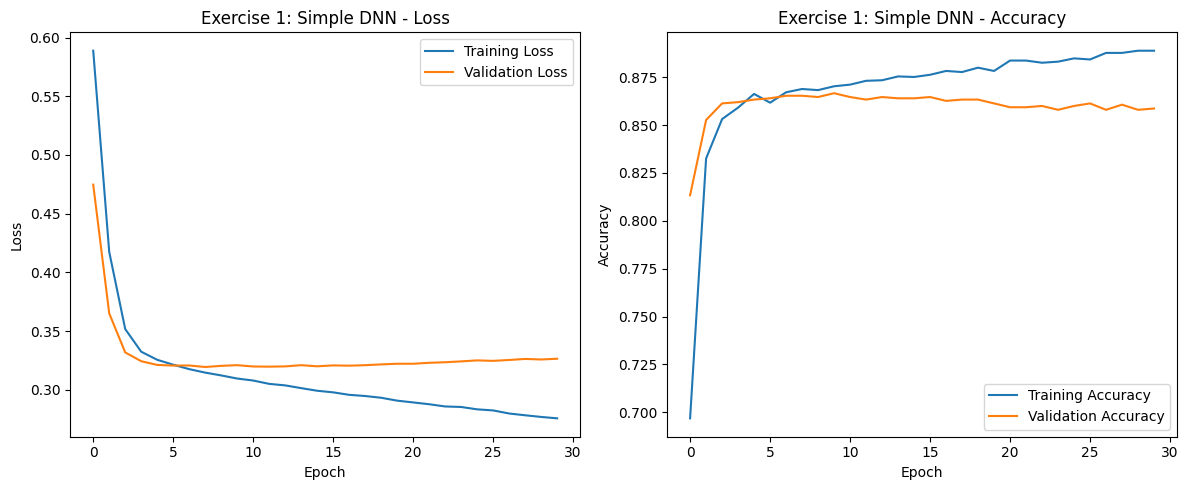


Interpretation:
The training loss decreased consistently over the epochs,
but if the validation loss plateaus or increases, it may indicate overfitting.
Consider early stopping or limiting training to fewer epochs if that occurs.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.datasets import make_classification
X, y = make_classification(n_samples=5000, n_features=20, random_state=42)

X_Train, X_Test, y_Train, y_Test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_Train = scaler.fit_transform(X_Train)
X_Test = scaler.transform(X_Test)

def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Binary output
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = create_model(X_Train.shape[1])
history = model.fit(
    X_Train, y_Train,
    epochs=30,
    batch_size=64,
    validation_data=(X_Test, y_Test),
    verbose=1
)

def plot_history(history, title="Model Performance"):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history, title="Exercise 1: Simple DNN")

print("\nInterpretation:")
print("The training loss decreased consistently over the epochs,")
print("but if the validation loss plateaus or increases, it may indicate overfitting.")
print("Consider early stopping or limiting training to fewer epochs if that occurs.")


## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [12]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

def create_simple_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),  # Explicit Input layer
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Output for binary classification
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model



In [13]:
model = create_simple_model(X_Train.shape[1])
history = model.fit(
    X_Train, y_Train,
    epochs=10,
    batch_size=1024,
    validation_data=(X_Test, y_Test),
    verbose=1
)


Epoch 1/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 748us/step - accuracy: 0.6930 - loss: 0.5598 - val_accuracy: 0.7899 - val_loss: 0.4504
Epoch 2/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - accuracy: 0.7957 - loss: 0.4439 - val_accuracy: 0.7960 - val_loss: 0.4411
Epoch 3/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - accuracy: 0.7988 - loss: 0.4368 - val_accuracy: 0.7961 - val_loss: 0.4385
Epoch 4/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - accuracy: 0.7998 - loss: 0.4347 - val_accuracy: 0.7968 - val_loss: 0.4380
Epoch 5/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.8017 - loss: 0.4314 - val_accuracy: 0.7967 - val_loss: 0.4372
Epoch 6/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.8005 - loss: 0.4334 - val_accuracy: 0.7970 - val_loss: 0.4364
Epoch 7/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.7989 - loss: 0.4344 - val_accuracy: 0.7978 - val_loss: 0.4359
Epoch 8/10
489/489 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.8000 - loss: 0.4326 - 

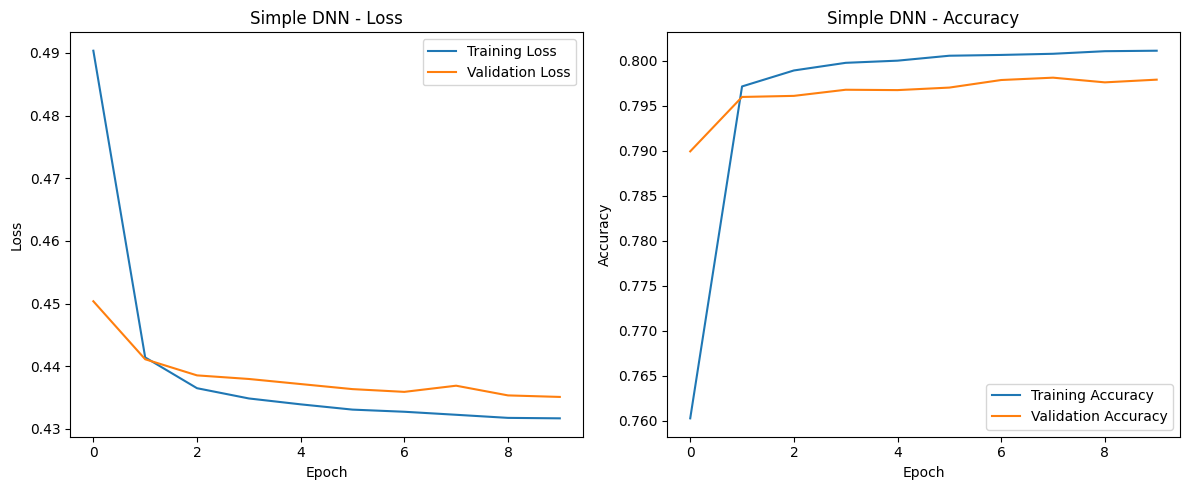

In [14]:
plot_history(history, title="Simple DNN")


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step


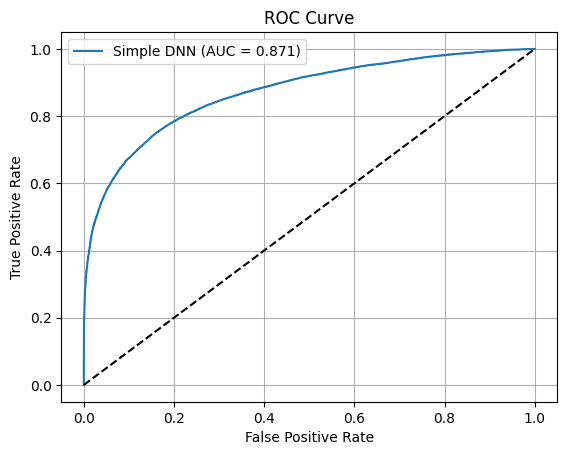

In [15]:
y_scores = model.predict(X_Test).ravel()  # Now this will work
roc_auc = plot_roc(y_Test, y_scores, "Simple DNN")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [22]:
# Model 1: Shallow ReLU with Adam
def create_model_1(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 2: Deeper Tanh with Dropout + RMSprop
def create_model_2(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='tanh'),
        Dropout(0.3),
        Dense(64, activation='tanh'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=RMSprop(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Model 3: Wide ReLU + SGD
def create_model_3(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [23]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_roc_curve(models_data):
    plt.figure(figsize=(6, 6))
    for label, y_true, y_scores in models_data:
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, RMSprop, SGD


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5306 - loss: 0.7448 - val_accuracy: 0.7480 - val_loss: 0.5625
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 968us/step - accuracy: 0.7866 - loss: 0.5170 - val_accuracy: 0.8413 - val_loss: 0.4043
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.8408 - loss: 0.3898 - val_accuracy: 0.8553 - val_loss: 0.3406
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.8536 - loss: 0.3388 - val_accuracy: 0.8620 - val_loss: 0.3281
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 895us/step - accuracy: 0.8639 - loss: 0.3187 - val_accuracy: 0.8647 - val_loss: 0.3253
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.8654 - loss: 0.3193 - val_accuracy: 0.8673 - val_loss: 0.3227
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.8714 - loss: 0.3003 - val_accuracy: 0.8673 - val_loss: 0.3222
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.8586 - loss: 0.3283 - val_accuracy: 0.87

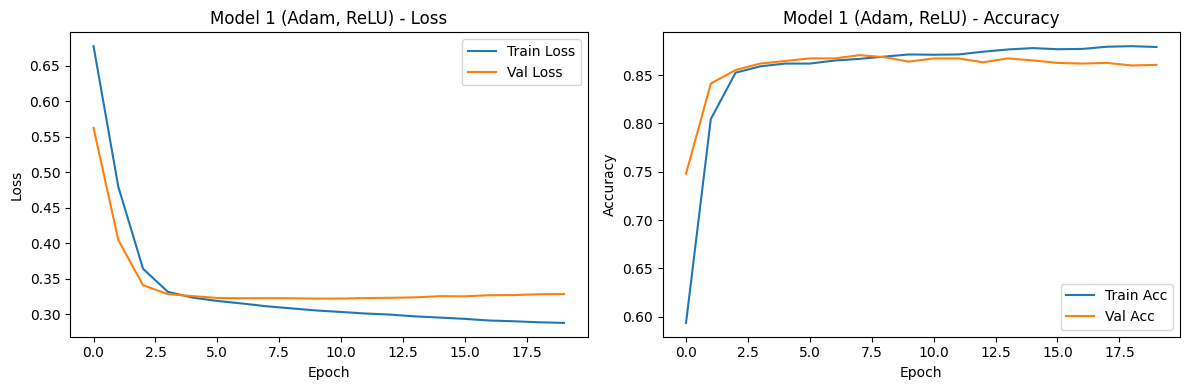

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7474 - loss: 0.5026 - val_accuracy: 0.8667 - val_loss: 0.3159
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8519 - loss: 0.3509 - val_accuracy: 0.8647 - val_loss: 0.3123
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8619 - loss: 0.3379 - val_accuracy: 0.8620 - val_loss: 0.3170
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8603 - loss: 0.3265 - val_accuracy: 0.8620 - val_loss: 0.3149
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8561 - loss: 0.3379 - val_accuracy: 0.8660 - val_loss: 0.3155
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8601 - loss: 0.3339 - val_accuracy: 0.8653 - val_loss: 0.3120
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8617 - loss: 0.3321 - val_accuracy: 0.8700 - val_loss: 0.3124
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8537 - loss: 

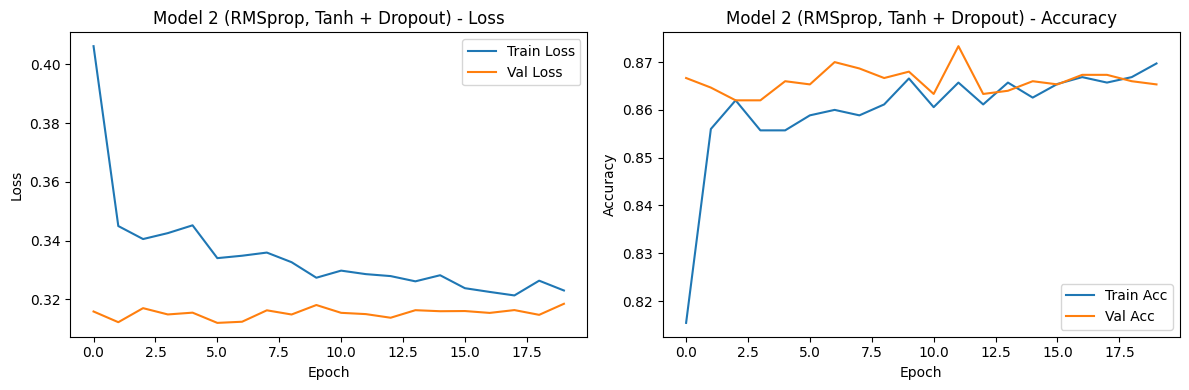

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6851 - loss: 0.5990 - val_accuracy: 0.8487 - val_loss: 0.3344
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8656 - loss: 0.3309 - val_accuracy: 0.8627 - val_loss: 0.3208
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8660 - loss: 0.3123 - val_accuracy: 0.8680 - val_loss: 0.3175
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8738 - loss: 0.3081 - val_accuracy: 0.8633 - val_loss: 0.3184
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8745 - loss: 0.2974 - val_accuracy: 0.8667 - val_loss: 0.3211
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8913 - loss: 0.2793 - val_accuracy: 0.8620 - val_loss: 0.3197
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8838 - loss: 0.2882 - val_accuracy: 0.8647 - val_loss: 0.3215
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8929 - loss: 

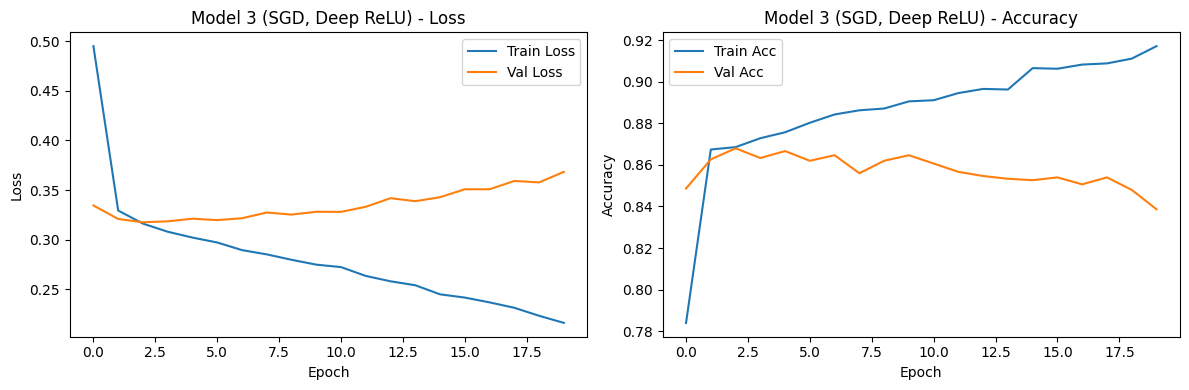

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 659us/step


In [27]:
# Train Model 1
model1 = create_model_1(X_Train.shape[1])
history1 = model1.fit(X_Train, y_Train, validation_data=(X_Test, y_Test), epochs=20, batch_size=64, verbose=1)
plot_history(history1, "Model 1 (Adam, ReLU)")
y1_scores = model1.predict(X_Test).ravel()

# Train Model 2
model2 = create_model_2(X_Train.shape[1])
history2 = model2.fit(X_Train, y_Train, validation_data=(X_Test, y_Test), epochs=20, batch_size=64, verbose=1)
plot_history(history2, "Model 2 (RMSprop, Tanh + Dropout)")
y2_scores = model2.predict(X_Test).ravel()

# Train Model 3
model3 = create_model_3(X_Train.shape[1])
history3 = model3.fit(X_Train, y_Train, validation_data=(X_Test, y_Test), epochs=20, batch_size=64, verbose=1)
plot_history(history3, "Model 3 (SGD, Deep ReLU)")
y3_scores = model3.predict(X_Test).ravel()


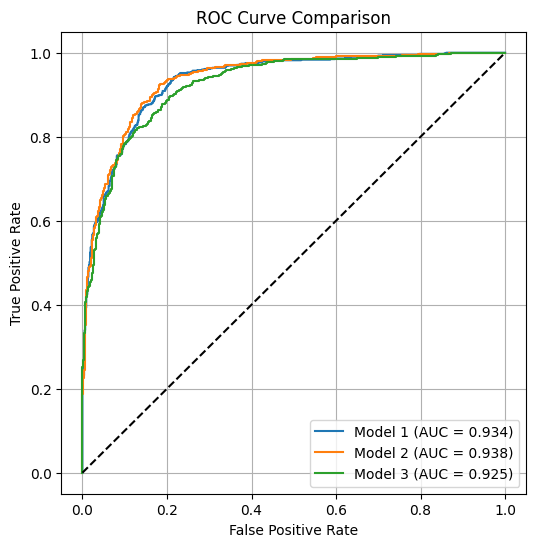

In [28]:
plot_roc_curve([
    ("Model 1", y_Test, y1_scores),
    ("Model 2", y_Test, y2_scores),
    ("Model 3", y_Test, y3_scores)
])


## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np


In [33]:
def compute_significance(y_true, y_pred):
    NS = sum((y_true == 1) & (y_pred == 1))  # True Positives
    NB = sum((y_true == 0) & (y_pred == 1))  # False Positives
    if NS + NB == 0:
        return 0
    return NS / ((NS + NB) ** 0.5)


In [34]:
def evaluate_classifier(clf, X_train, y_train, X_test, y_test, is_dnn=False):
    if is_dnn:
        clf.fit(X_train, y_train, epochs=10, batch_size=64, verbose=0, validation_split=0.2)
        y_probs = clf.predict(X_test).ravel()
    else:
        clf.fit(X_train, y_train)
        y_probs = clf.predict_proba(X_test)[:, 1]
    
    y_pred = (y_probs > 0.5).astype(int)
    auc = roc_auc_score(y_test, y_probs)
    sig = compute_significance(y_test, y_pred)
    return auc, sig


In [35]:
# Define classical models
clf_lr = LogisticRegression(max_iter=1000)
clf_dt = DecisionTreeClassifier()
clf_rf = RandomForestClassifier()

# Your best DNN from Exercise 3
clf_dnn = create_model_2(X_Train.shape[1])  # or whichever DNN performed best

# Evaluate and compare
results = []

for name, clf, is_dnn in [
    ("Logistic Regression", clf_lr, False),
    ("Decision Tree", clf_dt, False),
    ("Random Forest", clf_rf, False),
    ("Best DNN", clf_dnn, True)
]:
    auc, sig = evaluate_classifier(clf, X_Train, y_Train, X_Test, y_Test, is_dnn)
    results.append((name, auc, sig))


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 557us/step


In [36]:
for name, auc, sig in results:
    print(f"{name:20s} | AUC = {auc:.3f} | Significance σₛ = {sig:.3f}")


Logistic Regression  | AUC = 0.941 | Significance σₛ = 23.243
Decision Tree        | AUC = 0.881 | Significance σₛ = 23.632
Random Forest        | AUC = 0.972 | Significance σₛ = 24.530
Best DNN             | AUC = 0.939 | Significance σₛ = 23.285
